In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [52]:
data = pd.read_csv('insurance.csv')

In [53]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [54]:
data.head(5)#read top 5

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


EDA


In [55]:
data.shape #1338 rows and 7 columns
    

(1338, 7)

In [56]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [58]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [59]:
data.isnull().sum()#count of null values in each columns

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

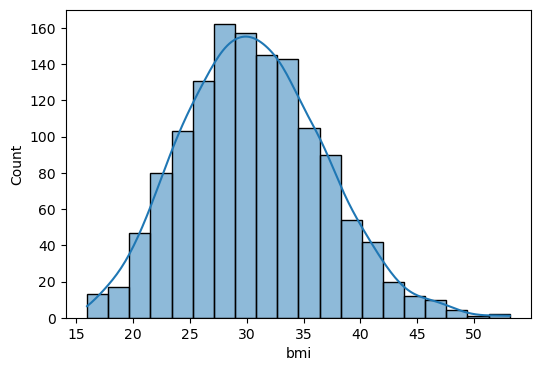

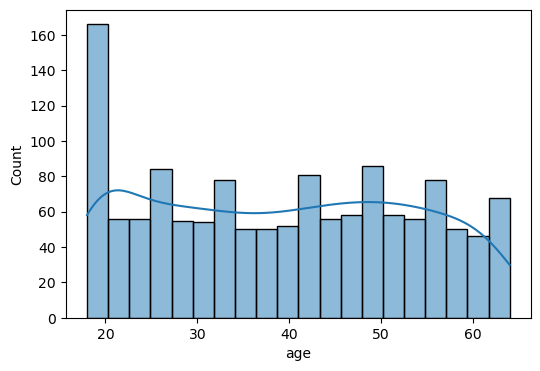

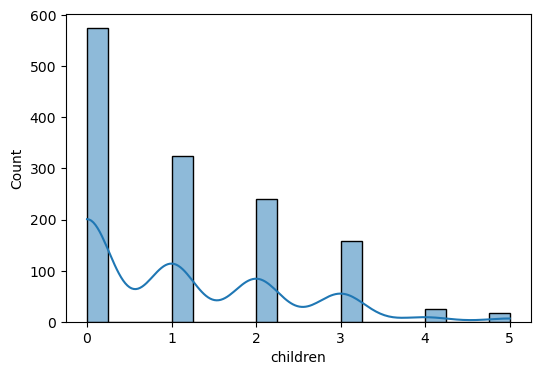

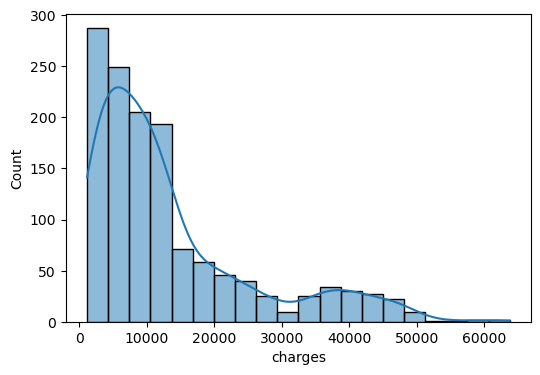

In [60]:
numeric_columns = ['bmi','age','children', 'charges']
for col in numeric_columns :
    plt.figure(figsize = (6,4))
    sns.histplot(data[col],kde = True, bins = 20)

<Axes: xlabel='children', ylabel='count'>

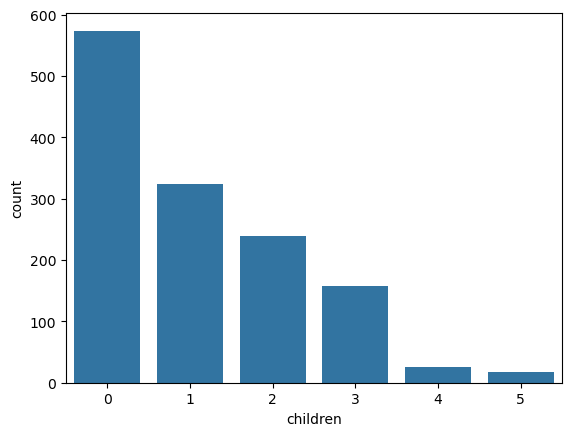

In [61]:
#children's hostogram doesnt give much insight, so we will use the countplot for it
sns.countplot(x = data['children'])

<Axes: xlabel='sex', ylabel='count'>

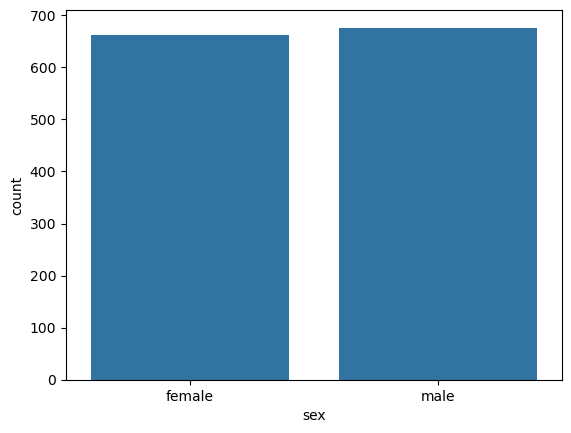

In [62]:
sns.countplot(x= data['sex'])
#they are almost equally distributed

<Axes: xlabel='smoker', ylabel='count'>

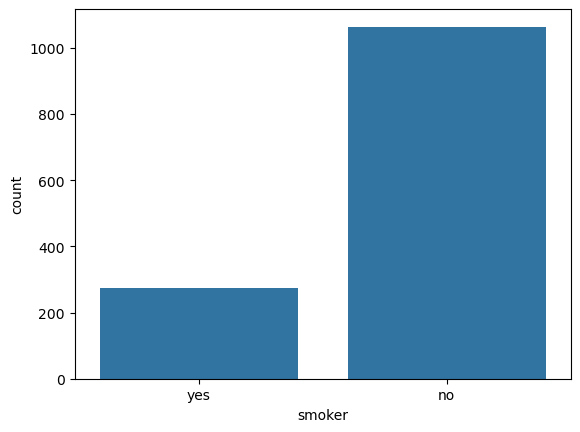

In [63]:
sns.countplot(x = data['smoker'])

### Box Plots

A **Box Plot** visually summarizes the distribution of a numerical column through quartiles. It is the best tool for identifying outliers and comparing data across different categories.

**The Anatomy of a Box Plot:**
* **Median (Middle Line):** The exact middle value of the dataset.
* **The Box (IQR):** Contains the middle 50% of the data (from the 25th percentile to the 75th percentile).
* **The Whiskers:** Represent the typical range of the data, extending to 1.5x the size of the box.
* **The Dots:** Data points falling outside the whiskers are mathematically considered **outliers**.

 Syntax:
`sns.boxplot(x='Categorical_Column', y='Numerical_Column', data=dataframe)`

<Axes: xlabel='smoker', ylabel='charges'>

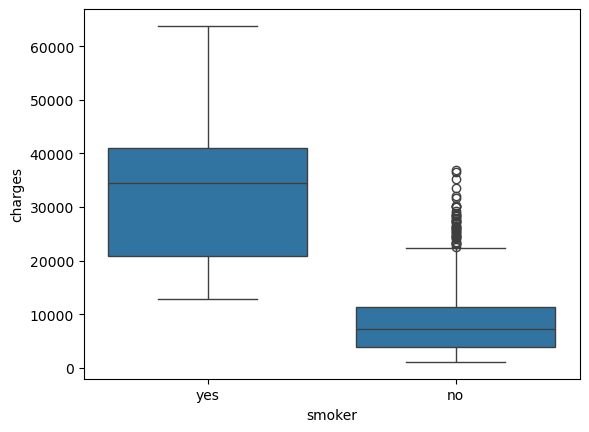

In [64]:
#for the smoker vs non smoker distribution
sns.boxplot(x= data['smoker'], y = data['charges'])

#huge gap in the two boxes show that smoking is a very important factor for the insurance charges.

the cheapest bill for a smoker is 13000 roughly which is higher than what the 75% of non smokers pay.

many dots over the nonsmoker box signify the people who pay higher insurance charges than what their group people do, for them not smoking is not the only deciding factor, but may be they are older or have abnormal bmi or some other medical cause.

non smokers insurance range is low and predicable whereas for smokers tha range is very high and also unpredictable.

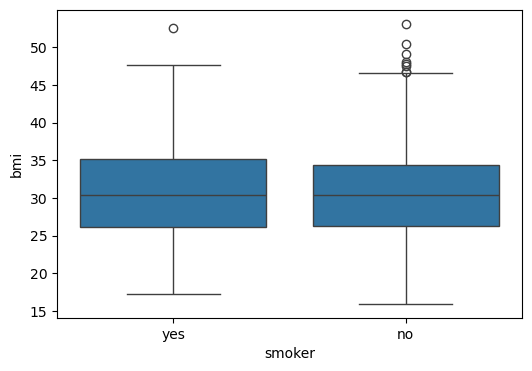

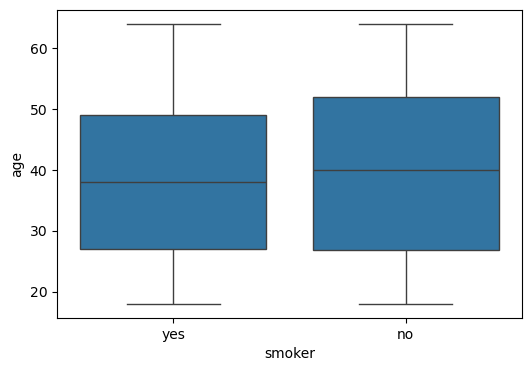

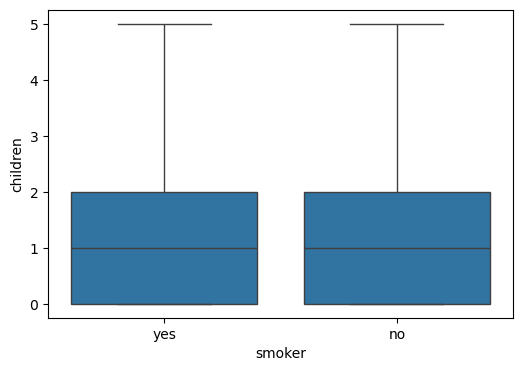

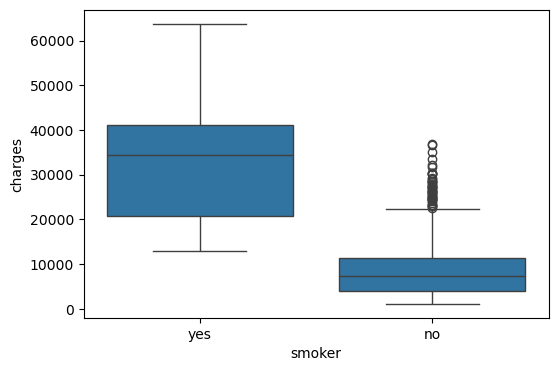

In [66]:
for col in numeric_columns :
    plt.figure(figsize = (6,4))
    sns.boxplot ( x = data['smoker'], y = data[col])